In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,f1_score

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],errors="coerce"
)

In [7]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df=df.drop(columns=["customerID"])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df["Churn"]=df["Churn"].map({"No":0,"Yes":1})


In [10]:
x=df.drop(columns=["Churn"])
y=df["Churn"]

In [11]:
x.shape

(7043, 19)

In [12]:
y.shape

(7043,)

In [13]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [14]:
numeric_feature=x.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

In [15]:
numeric_feature

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [16]:
categorical_feature=x.select_dtypes(
    include=["str"]
).columns.tolist()

In [17]:
numeric_transformer=Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

In [34]:
categorical_transformer=Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
           )
    ])

In [35]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_feature
        ),
        (
            "cat",
            categorical_transformer,
            categorical_feature
        )
    ]
)

In [36]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)

In [37]:
x_train.shape

(5634, 19)

In [38]:
y_train.shape

(5634,)

In [39]:
models={
"logistic regression":LogisticRegression(),
"decisiontree classifier":DecisionTreeClassifier(),
"random state":RandomForestClassifier(),
"gradient boosting":GradientBoostingClassifier()}
print(len(models))

4


In [40]:
results=[]
for name,model in models.items():
    pipeline=Pipeline(steps=[
        ("preprocessor",preprocessor),
        ("model",model)
    ])

    accuracy_scores=cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    f1_scores=cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    results.append({
        "model":name,
        "accuray":accuracy_scores.mean(),
        "f1 score":f1_scores.mean(),
        "f1 std":f1_scores.std()
    })
    print(name,"completed")

    

    

logistic regression completed
decisiontree classifier completed
random state completed
gradient boosting completed


In [41]:
print(Pipeline)

<class 'sklearn.pipeline.Pipeline'>


In [42]:
for name, model in models.items():
    print(name, type(model))

logistic regression <class 'sklearn.linear_model._logistic.LogisticRegression'>
decisiontree classifier <class 'sklearn.tree._classes.DecisionTreeClassifier'>
random state <class 'sklearn.ensemble._forest.RandomForestClassifier'>
gradient boosting <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [43]:
comparison_df=pd.DataFrame(results)
comparison_df=comparison_df.sort_values(
    by="f1 score",
    ascending=False
)
print(comparison_df)

                     model   accuray  f1 score    f1 std
0      logistic regression  0.801207  0.590610  0.016408
3        gradient boosting  0.799608  0.572513  0.027015
2             random state  0.783457  0.538066  0.029503
1  decisiontree classifier  0.729500  0.495086  0.013456


In [44]:
best_model_name=comparison_df.iloc[0]["model"]
print(best_model_name)

logistic regression


In [45]:
best_f1score=comparison_df.iloc[0]["f1 score"]
print(best_f1score)

0.5906095746930208


In [46]:
from sklearn.metrics import classification_report
best_model=models[best_model_name]
final_pipeline=Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            best_model
        )
        ])
final_pipeline.fit(x_train,y_train)
y_pred=final_pipeline.predict(x_test)

print(accuracy_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

0.8211497515968772
0.64
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



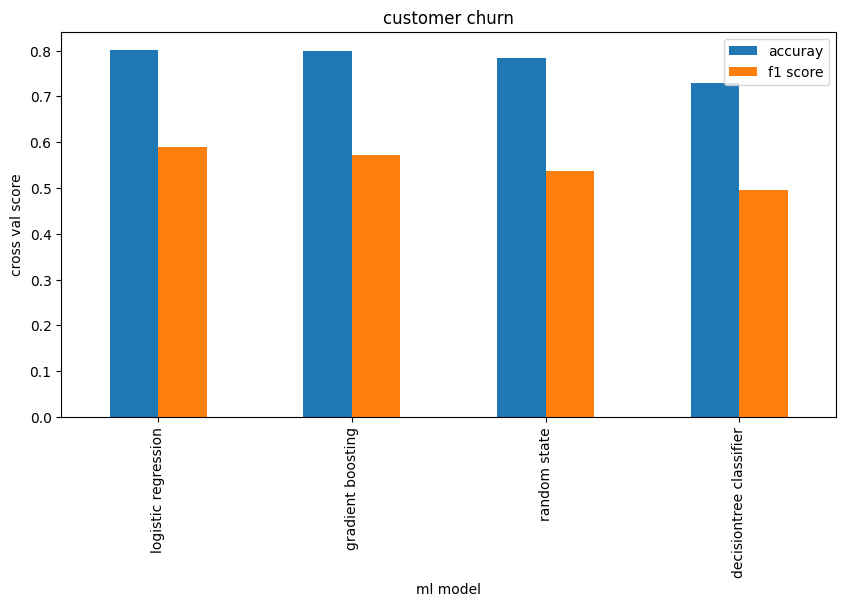

In [47]:
import matplotlib.pyplot as plt
comparison_df.plot(
    x="model",
    y=["accuray","f1 score"],
    kind="bar",
    figsize=(10,5)
)
plt.title("customer churn")
plt.xlabel("ml model")
plt.ylabel("cross val score")
plt.show()

In [48]:
print(comparison_df.columns)
print(comparison_df.head())

Index(['model', 'accuray', 'f1 score', 'f1 std'], dtype='str')
                     model   accuray  f1 score    f1 std
0      logistic regression  0.801207  0.590610  0.016408
3        gradient boosting  0.799608  0.572513  0.027015
2             random state  0.783457  0.538066  0.029503
1  decisiontree classifier  0.729500  0.495086  0.013456


In [49]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [50]:
preprocessor.fit_transform(x_train)

array([[-4.37749204e-01, -4.65683364e-01, -4.73723375e-04, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-4.37749204e-01,  8.85536787e-01,  1.07475386e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.37749204e-01, -1.28460467e+00, -1.37649913e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       ...,
       [-4.37749204e-01, -8.34197950e-01, -1.45294499e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 2.28441306e+00, -8.34197950e-01,  1.14953785e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-4.37749204e-01, -2.60953038e-01, -1.49781538e+00, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(5634, 45))

In [ ]:
df.isnull().sum()